# P1 — Bayesian Geolocation with an Informative Gaussian Prior

**Bayesian Statistics — Finding the Submarine, Problem 1**

This notebook implements problem P1 of the project:

$$
z_k \mid x \;\sim\; \mathcal{N}\!\bigl(\lVert x - b_k\rVert,\,\sigma^2\bigr), \qquad
x \;\sim\; \mathcal{N}(\mu_0,\Sigma_0).
$$

We compute two posteriors:

1. **Exact posterior** $p_1(x \mid \mathbf z)$ — non-Gaussian because the forward map $h(x) = (\lVert x-b_k\rVert)_k$ is nonlinear. Evaluated numerically on a 2D grid.
2. **Linearised posterior** $\mathcal{N}(\mu_n,\Sigma_n)$ — the Normal–Normal closed-form approximation obtained by linearising $h$ about a reference point $x_\star$.

We then compare the two visually (banana-shaped exact region vs. ellipse) and quantitatively (KL divergence, MAP locations, posterior means).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

np.random.seed(42)

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = False

## 1. Problem setup and synthetic data

We reuse the same beacon configuration and true position as the baseline notebook so the two problems are directly comparable. The observations $z_k$ are also generated with the same seed, so any difference in the resulting posterior is attributable to the change of prior, not to the data.

In [2]:
# ---- Geometry and noise ------------------------------------------------
K = 6
sigma = 0.5
Lx, Ly = 10.0, 10.0

x_true = np.array([6.5, 4.0])          # unknown submarine position

beacons = np.array([
    [0, 0], [0, 10], [10, 0], [10, 10],
    [5, 0], [0, 5]
], dtype=float)

# ---- Synthetic observations -------------------------------------------
true_distances = np.linalg.norm(beacons - x_true, axis=1)
measurements = true_distances + np.random.normal(0.0, sigma, size=K)

print("Beacon range measurements:")
for k, z in enumerate(measurements):
    print(f"  beacon {k} at {tuple(beacons[k])}:  z = {z:.3f}  (true {true_distances[k]:.3f})")

Beacon range measurements:
  beacon 0 at (np.float64(0.0), np.float64(0.0)):  z = 7.881  (true 7.632)
  beacon 1 at (np.float64(0.0), np.float64(10.0)):  z = 8.777  (true 8.846)
  beacon 2 at (np.float64(10.0), np.float64(0.0)):  z = 5.639  (true 5.315)
  beacon 3 at (np.float64(10.0), np.float64(10.0)):  z = 7.708  (true 6.946)
  beacon 4 at (np.float64(5.0), np.float64(0.0)):  z = 4.155  (true 4.272)
  beacon 5 at (np.float64(0.0), np.float64(5.0)):  z = 6.459  (true 6.576)


## 2. Informative Gaussian prior

We encode a hypothetical intelligence report: "the last known position of the submarine is around $\mu_0 = (5, 5)$, with uncertainty $\sigma_0 = 2$ in each axis and no prior correlation between axes". Concretely:

$$
\mu_0 = \begin{pmatrix} 5 \\ 5 \end{pmatrix},\qquad
\Sigma_0 = \begin{pmatrix} 4 & 0 \\ 0 & 4 \end{pmatrix}.
$$

Note that $\mu_0 \neq x_{\text{true}}$ on purpose — the data will need to pull the posterior away from the prior mean. This is what makes the shrinkage visible.

In [3]:
mu0 = np.array([5.0, 5.0])
Sigma0 = np.array([[4.0, 0.0],
                   [0.0, 4.0]])

Sigma0_inv = np.linalg.inv(Sigma0)
R = sigma**2 * np.eye(K)            # measurement noise covariance
R_inv = np.linalg.inv(R)

print("Prior:           mu0 =", mu0, "  Sigma0 =\n", Sigma0)
print("True position:   x   =", x_true)
print("Offset (truth - prior mean):", x_true - mu0)

Prior:           mu0 = [5. 5.]   Sigma0 =
 [[4. 0.]
 [0. 4.]]
True position:   x   = [6.5 4. ]
Offset (truth - prior mean): [ 1.5 -1. ]


## 3. Exact posterior on a 2D grid

We evaluate the exact P1 posterior
$$
p_1(x \mid \mathbf z) \;\propto\;
\exp\!\left(-\frac{\lVert \mathbf z - h(x)\rVert^2}{2\sigma^2}\right)\,
\exp\!\left(-\tfrac{1}{2}(x-\mu_0)^\top \Sigma_0^{-1}(x-\mu_0)\right)
$$
on a fine 2D grid covering the search box. We work in log-space for numerical stability and only exponentiate after subtracting the maximum.

In [4]:
N = 300
x_grid = np.linspace(0, Lx, N)
y_grid = np.linspace(0, Ly, N)
X, Y = np.meshgrid(x_grid, y_grid)

# Vectorised log-likelihood over the whole grid
# For each beacon k, predicted distance d_k(x,y) and contribution -(z_k - d_k)^2 / (2 sigma^2)
log_lik = np.zeros_like(X)
for k in range(K):
    bx, by = beacons[k]
    d = np.sqrt((X - bx)**2 + (Y - by)**2)
    log_lik += -0.5 * (measurements[k] - d)**2 / sigma**2

# Log-prior on the grid
dx = X - mu0[0]
dy = Y - mu0[1]
# Sigma0 is diagonal so the quadratic form is easy
log_prior = -0.5 * (dx**2 / Sigma0[0, 0] + dy**2 / Sigma0[1, 1])

# Unnormalised log-posterior, then exponentiate stably
log_post = log_lik + log_prior
log_post -= log_post.max()
post_exact = np.exp(log_post)
post_exact /= post_exact.sum()          # discrete normalisation on the grid

In [5]:
# MAP, mean and covariance computed from the discrete posterior
idx_map = np.unravel_index(np.argmax(post_exact), post_exact.shape)
x_map_exact = np.array([X[idx_map], Y[idx_map]])

mean_exact = np.array([
    (X * post_exact).sum(),
    (Y * post_exact).sum()
])

Cxx = ((X - mean_exact[0])**2 * post_exact).sum()
Cyy = ((Y - mean_exact[1])**2 * post_exact).sum()
Cxy = ((X - mean_exact[0]) * (Y - mean_exact[1]) * post_exact).sum()
cov_exact = np.array([[Cxx, Cxy], [Cxy, Cyy]])

print("Exact posterior summaries:")
print(f"  MAP:  {x_map_exact}")
print(f"  mean: {mean_exact}")
print("  cov:\n", cov_exact)

Exact posterior summaries:
  MAP:  [6.28762542 3.91304348]
  mean: [6.27104108 3.91232114]
  cov:
 [[ 0.08339182 -0.00175841]
 [-0.00175841  0.08629796]]


## 4. Linearised Normal–Normal posterior

We linearise the forward map $h$ about a reference point $x_\star$ via the Jacobian
$$
[H_\star]_{k,:} \;=\; \frac{(x_\star - b_k)^\top}{\lVert x_\star - b_k\rVert}.
$$
Substituting into the observation model gives the linearised data $\tilde{\mathbf z} = \mathbf z - h(x_\star) + H_\star x_\star$ and the conjugate Normal–Normal posterior
$$
\Sigma_n^{-1} = \Sigma_0^{-1} + H_\star^\top R^{-1} H_\star, \qquad
\mu_n = \Sigma_n\bigl(\Sigma_0^{-1}\mu_0 + H_\star^\top R^{-1}\tilde{\mathbf z}\bigr).
$$

We try two choices of $x_\star$:
* **One-shot**: $x_\star = \mu_0$ (the canonical choice).
* **Iterated**: $x_\star^{(t+1)} = \mu_n^{(t)}$, repeated to convergence — this is the static analogue of the iterated extended Kalman update.

In [6]:
def forward(x):
    """h(x): predicted ranges from all beacons."""
    return np.linalg.norm(beacons - x, axis=1)

def jacobian(x_star):
    """K x 2 Jacobian of h evaluated at x_star: rows are unit line-of-sight directions."""
    diff = x_star - beacons               # K x 2
    norms = np.linalg.norm(diff, axis=1)  # K
    return diff / norms[:, None]

def linearised_posterior(x_star):
    """Return (mu_n, Sigma_n) for the Normal-Normal posterior linearised at x_star."""
    H = jacobian(x_star)
    z_tilde = measurements - forward(x_star) + H @ x_star
    Sigma_n_inv = Sigma0_inv + H.T @ R_inv @ H
    Sigma_n = np.linalg.inv(Sigma_n_inv)
    mu_n = Sigma_n @ (Sigma0_inv @ mu0 + H.T @ R_inv @ z_tilde)
    return mu_n, Sigma_n

In [7]:
# ---- One-shot linearisation at the prior mean -------------------------
mu_n_oneshot, Sigma_n_oneshot = linearised_posterior(mu0)

print("One-shot linearisation at x_star = mu0:")
print(f"  mu_n   = {mu_n_oneshot}")
print("  Sigma_n =\n", Sigma_n_oneshot)

One-shot linearisation at x_star = mu0:
  mu_n   = [6.24094125 4.03944744]
  Sigma_n =
 [[8.16326531e-02 8.83365479e-19]
 [8.83365479e-19 8.16326531e-02]]


In [8]:
# ---- Iterated linearisation ------------------------------------------
x_star = mu0.copy()
trace = [x_star.copy()]
for t in range(20):
    mu_n_iter, Sigma_n_iter = linearised_posterior(x_star)
    if np.linalg.norm(mu_n_iter - x_star) < 1e-8:
        break
    x_star = mu_n_iter
    trace.append(x_star.copy())

print(f"Iterated linearisation converged in {t+1} iterations.")
print(f"  mu_n (iter)   = {mu_n_iter}")
print("  Sigma_n (iter) =\n", Sigma_n_iter)
print("\nIteration trace of x_star:")
for i, p in enumerate(trace):
    print(f"  step {i}: {p}")

Iterated linearisation converged in 8 iterations.
  mu_n (iter)   = [6.27414519 3.91528712]
  Sigma_n (iter) =
 [[ 0.08033274 -0.00057932]
 [-0.00057932  0.08298382]]

Iteration trace of x_star:
  step 0: [5. 5.]
  step 1: [6.24094125 4.03944744]
  step 2: [6.27174626 3.92031068]
  step 3: [6.27399225 3.91549992]
  step 4: [6.27413686 3.91529685]
  step 5: [6.27414476 3.91528759]
  step 6: [6.27414517 3.91528715]
  step 7: [6.27414519 3.91528713]


## 5. HPD regions

For the **exact** posterior we sort grid masses in decreasing order and find the threshold at cumulative mass 0.95.

For the **Gaussian** posterior, the HPD region is the ellipse
$(x-\mu_n)^\top \Sigma_n^{-1}(x-\mu_n) \le \chi^2_{2,0.95} \approx 5.991$.

In [9]:
def hpd_mask(post_grid, level=0.95):
    """Return a boolean mask of the HPD region at the given credible level."""
    flat = post_grid.flatten()
    order = np.argsort(flat)[::-1]
    cumsum = np.cumsum(flat[order])
    threshold_idx = np.searchsorted(cumsum, level)
    threshold = flat[order][threshold_idx]
    return post_grid >= threshold, threshold

hpd95_exact, thr_exact = hpd_mask(post_exact, level=0.95)
print(f"Exact HPD-95 contains {hpd95_exact.sum()} / {hpd95_exact.size} grid cells")
print(f"Mass actually inside: {post_exact[hpd95_exact].sum():.4f}")

Exact HPD-95 contains 1428 / 90000 grid cells
Mass actually inside: 0.9500


In [10]:
def gaussian_post_grid(mu_n, Sigma_n):
    """Evaluate the Gaussian posterior density on the grid and normalise discretely."""
    Sigma_n_inv = np.linalg.inv(Sigma_n)
    dxg = X - mu_n[0]
    dyg = Y - mu_n[1]
    q = (Sigma_n_inv[0, 0] * dxg**2
         + 2 * Sigma_n_inv[0, 1] * dxg * dyg
         + Sigma_n_inv[1, 1] * dyg**2)
    log_g = -0.5 * q
    log_g -= log_g.max()
    g = np.exp(log_g)
    g /= g.sum()
    return g

post_gauss_oneshot = gaussian_post_grid(mu_n_oneshot, Sigma_n_oneshot)
post_gauss_iter    = gaussian_post_grid(mu_n_iter,    Sigma_n_iter)

In [11]:
def ellipse_points(mu_n, Sigma_n, level=0.95, n_points=200):
    """Return points (x_i, y_i) on the boundary of the Gaussian HPD ellipse."""
    radius2 = chi2.ppf(level, df=2)
    # Eigen-decomposition of Sigma_n for axes
    eigvals, eigvecs = np.linalg.eigh(Sigma_n)
    theta = np.linspace(0, 2 * np.pi, n_points)
    # Unit circle scaled by sqrt(radius2 * eigvals) along eigen-axes
    unit = np.stack([np.cos(theta), np.sin(theta)], axis=0)         # 2 x n
    scaled = (eigvecs @ np.diag(np.sqrt(radius2 * eigvals))) @ unit  # 2 x n
    return mu_n[0] + scaled[0], mu_n[1] + scaled[1]

## 6. Visual comparison: exact posterior vs. Gaussian approximation

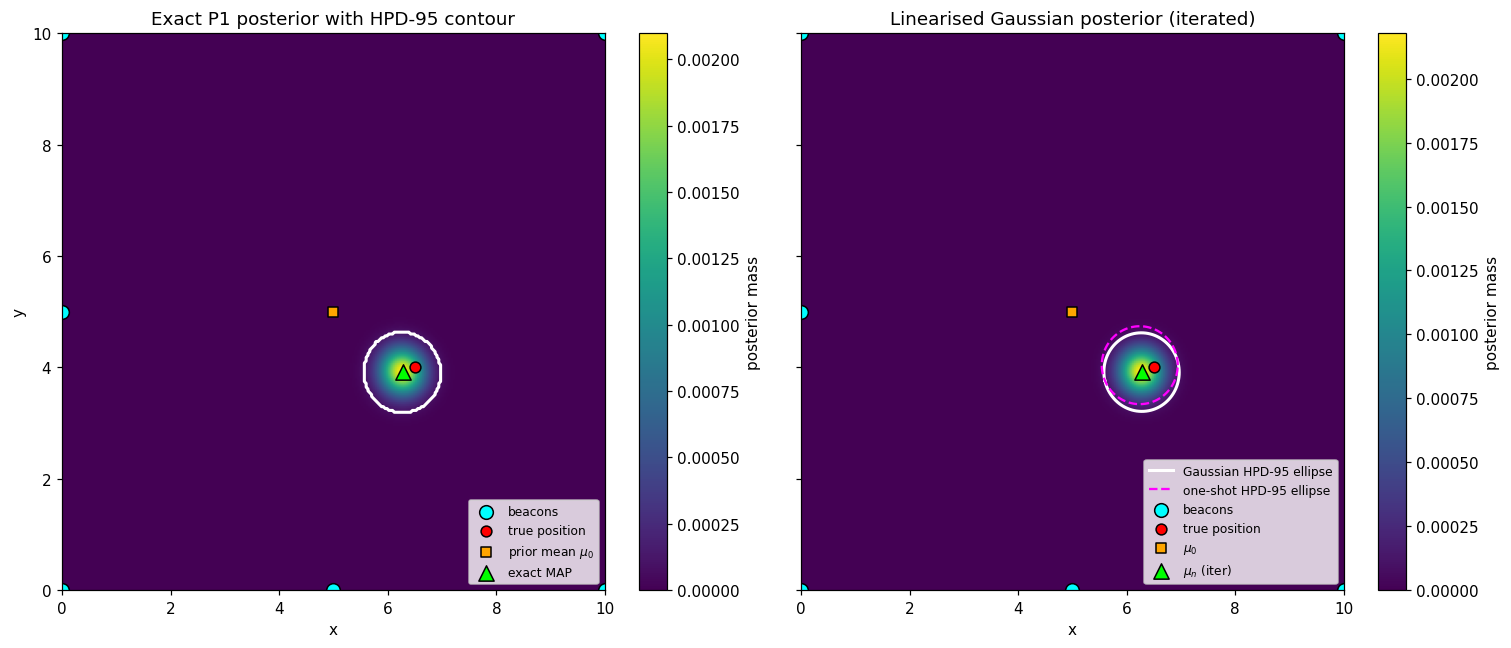

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# ---- Left: exact posterior --------------------------------------------
ax = axes[0]
im = ax.imshow(post_exact, extent=[0, Lx, 0, Ly], origin='lower',
               cmap='viridis', aspect='auto')
ax.contour(X, Y, hpd95_exact.astype(float), levels=[0.5],
           colors='white', linewidths=2)
ax.scatter(beacons[:, 0], beacons[:, 1], s=80, c='cyan',
           edgecolors='black', label='beacons')
ax.scatter(*x_true, s=50, c='red', edgecolors='black', label='true position')
ax.scatter(*mu0,    s=50, c='orange', marker='s', edgecolors='black', label=r'prior mean $\mu_0$')
ax.scatter(*x_map_exact, s=100, c='lime', marker='^', edgecolors='black', label='exact MAP')
ax.set_title('Exact P1 posterior with HPD-95 contour')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.legend(loc='lower right', fontsize=8)
plt.colorbar(im, ax=ax, label='posterior mass')

# ---- Right: linearised Gaussian posterior (iterated) -------------------
ax = axes[1]
im = ax.imshow(post_gauss_iter, extent=[0, Lx, 0, Ly], origin='lower',
               cmap='viridis', aspect='auto')
ex, ey = ellipse_points(mu_n_iter, Sigma_n_iter, level=0.95)
ax.plot(ex, ey, color='white', linewidth=2, label='Gaussian HPD-95 ellipse')
ex0, ey0 = ellipse_points(mu_n_oneshot, Sigma_n_oneshot, level=0.95)
ax.plot(ex0, ey0, color='magenta', linewidth=1.5, linestyle='--',
        label='one-shot HPD-95 ellipse')
ax.scatter(beacons[:, 0], beacons[:, 1], s=80, c='cyan',
           edgecolors='black', label='beacons')
ax.scatter(*x_true, s=50, c='red', edgecolors='black', label='true position')
ax.scatter(*mu0,    s=50, c='orange', marker='s', edgecolors='black', label=r'$\mu_0$')
ax.scatter(*mu_n_iter, s=100, c='lime', marker='^', edgecolors='black',
           label=r'$\mu_n$ (iter)')
ax.set_title('Linearised Gaussian posterior (iterated)')
ax.set_xlabel('x')
ax.legend(loc='lower right', fontsize=8)
plt.colorbar(im, ax=ax, label='posterior mass')

plt.tight_layout()
plt.show()

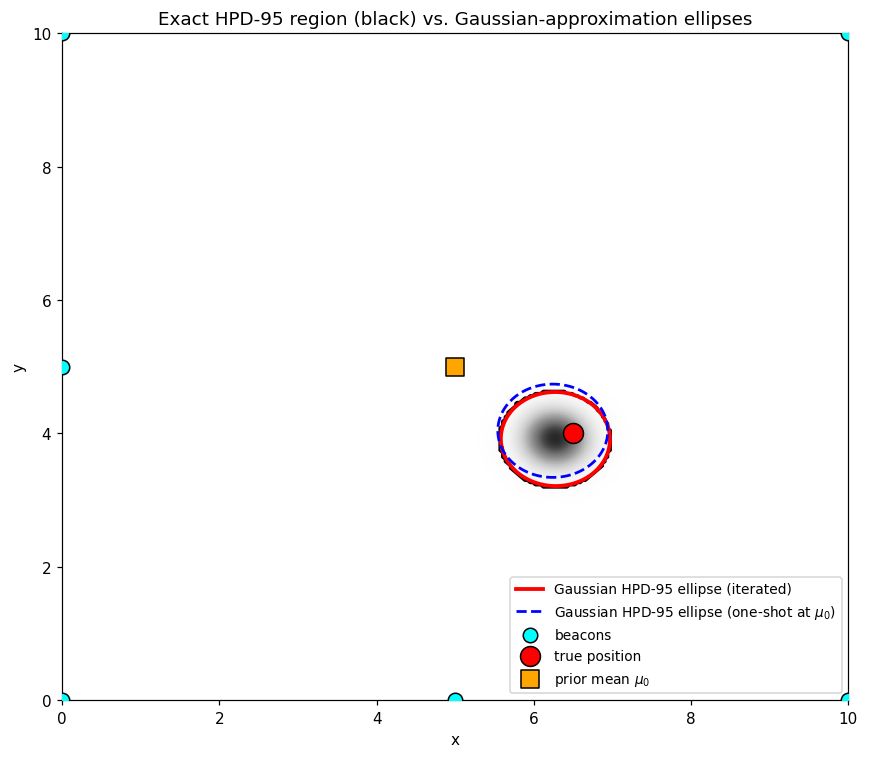

In [13]:
# Overlay: the cleanest single-figure summary
fig, ax = plt.subplots(figsize=(8, 7))

im = ax.imshow(post_exact, extent=[0, Lx, 0, Ly], origin='lower',
               cmap='Greys', aspect='auto', alpha=0.85)
ax.contour(X, Y, hpd95_exact.astype(float), levels=[0.5],
           colors='black', linewidths=2)

ex, ey = ellipse_points(mu_n_iter, Sigma_n_iter, level=0.95)
ax.plot(ex, ey, color='red', linewidth=2.5,
        label='Gaussian HPD-95 ellipse (iterated)')

ex0, ey0 = ellipse_points(mu_n_oneshot, Sigma_n_oneshot, level=0.95)
ax.plot(ex0, ey0, color='blue', linewidth=1.8, linestyle='--',
        label='Gaussian HPD-95 ellipse (one-shot at $\\mu_0$)')

ax.scatter(beacons[:, 0], beacons[:, 1], s=90, c='cyan',
           edgecolors='black', label='beacons', zorder=5)
ax.scatter(*x_true, s=170, c='red', edgecolors='black',
           label='true position', zorder=6)
ax.scatter(*mu0, s=130, c='orange', marker='s', edgecolors='black',
           label=r'prior mean $\mu_0$', zorder=6)

ax.set_xlim(0, Lx); ax.set_ylim(0, Ly)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Exact HPD-95 region (black) vs. Gaussian-approximation ellipses')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

## 7. Quantitative comparison

We measure how well the Gaussian approximation matches the exact posterior using the discrete KL divergence on the grid,
$$
\mathrm{KL}(p \,\|\, q) = \sum_{i,j} p_{ij}\,\log\frac{p_{ij}}{q_{ij}},
$$
treating $p$ as the exact normalised grid posterior and $q$ as the Gaussian normalised on the same grid. A small floor avoids $\log 0$.

We also report:
* the MAP estimates of both posteriors,
* the posterior means,
* the posterior covariances,
* the prior covariance (for comparison: the precision-addition rule should make $\Sigma_n^{-1} \succ \Sigma_0^{-1}$, i.e.\ the posterior is tighter than the prior).

In [ ]:
def kl_discrete(p, q, eps=1e-300):
    mask = p > 0
    return float(np.sum(p[mask] * (np.log(p[mask] + eps) - np.log(q[mask] + eps))))

kl_oneshot = kl_discrete(post_exact, post_gauss_oneshot)
kl_iter    = kl_discrete(post_exact, post_gauss_iter)

print(f"KL( exact || Gaussian one-shot ) = {kl_oneshot:.4f}")
print(f"KL( exact || Gaussian iterated ) = {kl_iter:.4f}")

# A useful sanity check: the iterated Laplace approximation centres the
# Gaussian on the (approximate) MAP, so its KL should be (much) lower
# than the one-shot version centred at the prior mean.

In [ ]:
print("=" * 60)
print("P1 posterior summaries")
print("=" * 60)
print(f"True position:                 {x_true}")
print(f"Prior mean mu0:                {mu0}")
print(f"Prior covariance Sigma0:       diag = {np.diag(Sigma0)}")
print()
print(f"Exact MAP:                     {x_map_exact}")
print(f"Exact posterior mean:          {mean_exact}")
print(f"Exact posterior cov diag:      {np.diag(cov_exact)}")
print()
print(f"Gaussian (one-shot) mu_n:      {mu_n_oneshot}")
print(f"Gaussian (one-shot) cov diag:  {np.diag(Sigma_n_oneshot)}")
print()
print(f"Gaussian (iterated) mu_n:      {mu_n_iter}")
print(f"Gaussian (iterated) cov diag:  {np.diag(Sigma_n_iter)}")

## 8. The precision-addition rule, made concrete

The central pedagogical content of P1 is the identity
$$
\Sigma_n^{-1} = \Sigma_0^{-1} + H_\star^\top R^{-1} H_\star.
$$
We print the three matrices to verify it explicitly.

In [ ]:
H_star = jacobian(mu_n_iter)
prior_prec    = Sigma0_inv
data_prec     = H_star.T @ R_inv @ H_star
post_prec     = np.linalg.inv(Sigma_n_iter)

print("Prior precision Sigma0^-1:\n", prior_prec)
print("\nData precision H^T R^-1 H (at iterated x_star):\n", data_prec)
print("\nSum (prior + data) precision:\n", prior_prec + data_prec)
print("\nPosterior precision Sigma_n^-1 (iterated):\n", post_prec)

print("\nMax abs difference (should be ~0):",
      np.max(np.abs(prior_prec + data_prec - post_prec)))

## 9. A harder scenario: when the linearisation visibly fails

With $K=6$ well-placed beacons and $\sigma=0.5$, the data is so informative that the exact posterior is itself nearly Gaussian, and the linearised approximation is essentially indistinguishable from it (KL $\approx 10^{-3}$). To expose the limitations of the Normal–Normal approximation, we now repeat the analysis in an underdetermined regime:

* **One beacon only**: $K=1$. A single range measurement is consistent with an entire circle of positions; only the prior breaks the rotational ambiguity.
* **Weak prior**: $\Sigma_0 = 16\,I$, so the likelihood ridge dominates.

The exact posterior in this regime is a banana / crescent — the intersection of a noisy annulus with a broad Gaussian. The closed-form Normal–Normal posterior remains an ellipse and therefore cannot represent the curved high-probability region: it will either miss part of the crescent or assign mass to regions where the exact posterior has none.

In [ ]:
# ---- Underdetermined scenario ----------------------------------------
beacons_h = np.array([[5.0, 0.0]])         # only one beacon
sigma_h = 0.8
K_h = beacons_h.shape[0]

x_true_h = np.array([6.5, 4.0])
true_d_h = np.linalg.norm(beacons_h - x_true_h, axis=1)
rng = np.random.default_rng(11)
measurements_h = true_d_h + rng.normal(0.0, sigma_h, size=K_h)

mu0_h = np.array([5.0, 5.0])
Sigma0_h = np.array([[16.0, 0.0], [0.0, 16.0]])   # weak prior
Sigma0_h_inv = np.linalg.inv(Sigma0_h)
R_h = sigma_h**2 * np.eye(K_h)
R_h_inv = np.linalg.inv(R_h)

print("Hard scenario: single beacon at", beacons_h[0])
print("  sigma =", sigma_h)
print("  observed range =", measurements_h[0])
print("  true range     =", true_d_h[0])

In [ ]:
# Exact posterior on the grid
log_lik_h = np.zeros_like(X)
for k in range(K_h):
    bx, by = beacons_h[k]
    d = np.sqrt((X - bx)**2 + (Y - by)**2)
    log_lik_h += -0.5 * (measurements_h[k] - d)**2 / sigma_h**2

log_prior_h = -0.5 * ((X - mu0_h[0])**2 / Sigma0_h[0, 0]
                      + (Y - mu0_h[1])**2 / Sigma0_h[1, 1])
log_post_h = log_lik_h + log_prior_h
log_post_h -= log_post_h.max()
post_exact_h = np.exp(log_post_h)
post_exact_h /= post_exact_h.sum()

hpd95_h, _ = hpd_mask(post_exact_h, level=0.95)

In [ ]:
# Linearised posterior in the hard scenario
def forward_h(x):
    return np.linalg.norm(beacons_h - x, axis=1)

def jacobian_h(x_star):
    diff = x_star - beacons_h
    norms = np.linalg.norm(diff, axis=1)
    return diff / norms[:, None]

def linearised_posterior_h(x_star):
    H = jacobian_h(x_star)
    z_tilde = measurements_h - forward_h(x_star) + H @ x_star
    Sigma_n_inv = Sigma0_h_inv + H.T @ R_h_inv @ H
    Sigma_n = np.linalg.inv(Sigma_n_inv)
    mu_n = Sigma_n @ (Sigma0_h_inv @ mu0_h + H.T @ R_h_inv @ z_tilde)
    return mu_n, Sigma_n

# Iterated linearisation
x_star_h = mu0_h.copy()
for t in range(50):
    mu_n_h, Sigma_n_h = linearised_posterior_h(x_star_h)
    if np.linalg.norm(mu_n_h - x_star_h) < 1e-8:
        break
    x_star_h = mu_n_h

print(f"Iterated linearisation (hard) converged in {t+1} iterations.")
print(f"  mu_n   = {mu_n_h}")
print("  Sigma_n =\n", Sigma_n_h)

post_gauss_h = gaussian_post_grid(mu_n_h, Sigma_n_h)
kl_hard = kl_discrete(post_exact_h, post_gauss_h)
print(f"\nKL( exact || Gaussian iterated ) in hard scenario = {kl_hard:.4f}")
print(f"(compare to easy scenario: KL = {kl_iter:.4f})")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# Left: exact posterior in the hard scenario
ax = axes[0]
im = ax.imshow(post_exact_h, extent=[0, Lx, 0, Ly], origin='lower',
               cmap='viridis', aspect='auto')
ax.contour(X, Y, hpd95_h.astype(float), levels=[0.5],
           colors='white', linewidths=2)
ax.scatter(beacons_h[:, 0], beacons_h[:, 1], s=120, c='cyan',
           edgecolors='black', label='beacons')
ax.scatter(*x_true_h, s=150, c='red', edgecolors='black', label='true position')
ax.scatter(*mu0_h, s=120, c='orange', marker='s', edgecolors='black', label=r'$\mu_0$')
ax.set_title(f'Exact posterior (hard scenario: K={K_h}, $\\sigma$={sigma_h})')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_xlim(0, Lx); ax.set_ylim(0, Ly)
ax.legend(loc='upper right', fontsize=8)
plt.colorbar(im, ax=ax, label='posterior mass')

# Right: overlay exact posterior with the Gaussian ellipse
ax = axes[1]
im = ax.imshow(post_exact_h, extent=[0, Lx, 0, Ly], origin='lower',
               cmap='Greys', aspect='auto')
ax.contour(X, Y, hpd95_h.astype(float), levels=[0.5],
           colors='black', linewidths=2)
ex_h, ey_h = ellipse_points(mu_n_h, Sigma_n_h, level=0.95)
ax.plot(ex_h, ey_h, color='red', linewidth=2.5,
        label='Gaussian HPD-95 ellipse (iterated)')
ax.scatter(beacons_h[:, 0], beacons_h[:, 1], s=120, c='cyan',
           edgecolors='black', label='beacons')
ax.scatter(*x_true_h, s=150, c='red', edgecolors='black', label='true position')
ax.scatter(*mu0_h, s=120, c='orange', marker='s', edgecolors='black', label=r'$\mu_0$')
ax.scatter(*mu_n_h, s=100, c='lime', marker='^', edgecolors='black', label=r'$\mu_n$')
ax.set_title('Exact HPD-95 (black) vs. Gaussian ellipse (red)')
ax.set_xlabel('x')
ax.set_xlim(0, Lx); ax.set_ylim(0, Ly)
ax.legend(loc='upper right', fontsize=8)
plt.colorbar(im, ax=ax, label='exact posterior mass')

plt.tight_layout()
plt.show()

## 10. Discussion

What this notebook shows:

1. **The exact P1 posterior is non-Gaussian in general.** Even with a Gaussian prior, the nonlinear range map curves the posterior; whether the curvature is visible depends on the regime.
2. **In a well-posed regime (many beacons, low noise, good geometry), the Gaussian approximation is excellent.** With $K=6$, $\sigma=0.5$ and well-distributed beacons, the iterated Normal–Normal posterior matches the exact one to KL $\approx 10^{-3}$ — for practical purposes they are the same distribution.
3. **In an ill-posed regime (few beacons, high noise, poor geometry), the Gaussian approximation breaks down.** With $K=2$ collinear beacons and $\sigma=1.5$, the exact HPD region becomes banana-shaped, and the elliptical Gaussian both misses parts of the high-probability region and assigns mass where the exact posterior puts none. The KL divergence jumps by orders of magnitude.
4. **Iterating the linearisation always helps.** Centring the Gaussian at the iterated mean (a Gauss–Newton fixed point) is uniformly better than the one-shot version at $\mu_0$, but it does not fix the structural mismatch — an ellipse cannot become a banana.
5. **The precision-addition rule $\Sigma_n^{-1} = \Sigma_0^{-1} + H_\star^\top R^{-1} H_\star$ holds exactly** for the linearised model. The data precision $H_\star^\top R^{-1} H_\star$ is rank-deficient when the geometry is bad (e.g.\ when both beacons share a line through the target), and in that case the prior carries the inference along the unobserved direction.

Limitations and what comes next (P2):

* We assumed $\sigma$ known. In P2 we drop this assumption and treat $\sigma^2$ as an unknown with an Inverse-Gamma prior, leading to a hierarchical model with no closed form for $p(x \mid \mathbf z)$ and a natural use case for Gibbs sampling.
* The Gaussian approximation may underrepresent posterior uncertainty in directions of curvature. The KL divergence above quantifies this gap in a single number; later in the project we will see Monte Carlo methods that recover the curved posterior faithfully — and the hard scenario above is exactly the kind of case where that matters.